# Mean-Variance Portfolio Optimization

This notebook implements the core optimization framework of Modern Portfolio Theory.

Using the expected return vector $\mu$ and covariance matrix $\Sigma$ estimated from historical data, we construct portfolios and analyze the trade-off between expected return and risk.

This notebook focuses on:

1. loading expected return and covariance inputs  
2. generating random portfolios  
3. computing portfolio return and volatility  
4. visualizing the feasible set of portfolios  
5. preparing for efficient frontier analysis

The results of this notebook will provide the baseline portfolio optimization framework that will later be extended to regime-dependent market environments.

## Motivation

Investors face a trade-off between **expected return** and **risk**.

Modern Portfolio Theory models this trade-off using two key inputs:

- the vector of expected asset returns, $\mu$
- the covariance matrix of asset returns, $\Sigma$

For any portfolio with weight vector $w$:

- expected return is given by

$$
E[R_p] = w^\top \mu
$$

- portfolio variance is given by

$$
\mathrm{Var}(R_p) = w^\top \Sigma w
$$

The goal of portfolio optimization is to choose portfolio weights that produce the most desirable balance between expected return and risk.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas_datareader import data as pdr

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

pd.options.display.float_format = "{:.6f}".format

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

## Load Portfolio Inputs

This notebook uses the processed return data from Notebook 1 and the annualized covariance matrix from Notebook 2.

These two objects provide the key inputs for mean-variance portfolio analysis:

- expected annual returns
- annualized covariance matrix

In [2]:
returns = pd.read_csv("../data/processed/asset_returns.csv", index_col=0, parse_dates=True)
annual_cov_matrix = pd.read_csv("../data/processed/annual_cov_matrix.csv", index_col=0)

## Expected Annual Returns

We estimate expected returns using the sample mean of daily returns and annualize them using 252 trading days per year:

$$
\mu_{annual} = 252 \cdot \mu_{daily}
$$

These estimates will be used together with the covariance matrix to evaluate portfolios.

In [6]:
annual_mean_returns = returns.mean() * 252

annual_mean_returns

EFA   0.064177
GLD   0.090408
SPY   0.128637
TLT   0.028226
VNQ   0.084922
dtype: float64

In [7]:
# Align inputs
annual_cov_matrix = annual_cov_matrix.loc[annual_mean_returns.index, annual_mean_returns.index]

annual_cov_matrix

,EFA,GLD,SPY,TLT,VNQ
EFA,0.033925,0.004336,0.027214,-0.007964,0.026096
GLD,0.004336,0.026891,0.001482,0.005109,0.003729
SPY,0.027214,0.001482,0.029566,-0.007642,0.026444
TLT,-0.007964,0.005109,-0.007642,0.022621,-0.002891
VNQ,0.026096,0.003729,0.026444,-0.002891,0.042244


## Portfolio Return and Volatility Functions

For a portfolio with weight vector $w$, expected return and volatility are defined by:

$$
E[R_p] = w^\top \mu
$$

and

$$
\sigma_p = \sqrt{w^\top \Sigma w}
$$

These formulas allow us to evaluate any portfolio once the expected return vector and covariance matrix are known.

In [20]:
def calc_portfolio_return(weights, mean_returns):
    """
    Compute the expected portfolio return.
    """
    return weights.T @ mean_returns


def calc_portfolio_volatility(weights, cov_matrix):
    """
    Compute the portfolio volatility.
    """
    return np.sqrt(weights.T @ cov_matrix @ weights)


def portfolio_performance(weights, mean_returns, cov_matrix):
    """
    Compute both expected return and volatility for a portfolio.
    """
    port_return = calc_portfolio_return(weights, mean_returns)
    port_vol = calc_portfolio_volatility(weights, cov_matrix)
    return port_return, port_vol

## Example: Equal-Weight Portfolio

As a baseline, we evaluate a portfolio that assigns equal weight to each asset.

In [11]:
n_assets = len(annual_mean_returns)
equal_weights = np.ones(n_assets) / n_assets

equal_weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [12]:
eq_return, eq_volatility = portfolio_performance(
    equal_weights,
    annual_mean_returns.values,
    annual_cov_matrix.values
)

print(f"Expected annual return: {eq_return:.2%}")
print(f"Annualized volatility: {eq_volatility:.2%}")

Expected annual return: 7.93%
Annualized volatility: 11.08%


### Interpretation

The equal-weight portfolio produces an estimated **expected annual return of approximately 7.93%**, with an **annualized volatility of about 11.08%**.

This result reflects a moderately diversified allocation across equities (SPY, EFA), real estate (VNQ), bonds (TLT), and gold (GLD). While the equity-heavy assets contribute most of the expected return, the inclusion of bonds and gold helps reduce overall portfolio volatility through diversification.

The equal-weight portfolio serves as a **baseline benchmark**. In the next sections, we will explore alternative portfolios that may achieve either:

- **higher expected returns for the same level of risk**, or  
- **lower risk for the same expected return**.

These portfolios form part of the **efficient frontier**, which represents the set of optimal portfolios under mean-variance theory.

---

## Random Portfolio Simulation

To visualize the range of possible portfolios, we simulate a large number of random asset allocations.

Each random portfolio generates a unique combination of:

- expected return
- portfolio volatility

Plotting these portfolios reveals the **feasible region** of risk–return combinations achievable with the available assets.

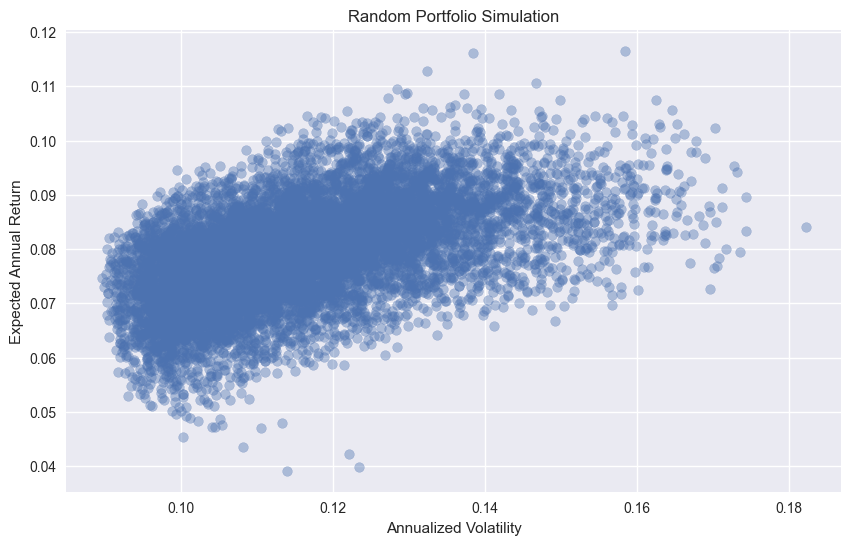

In [21]:
# Arrays to store results
n_portfolios = 10000
n_assets = len(annual_mean_returns)

sim_returns = np.zeros(n_portfolios)
sim_volatility = np.zeros(n_portfolios)
sim_weights = np.zeros((n_portfolios, n_assets))

# Generate random portfolios
for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)

    sim_weights[i] = weights

    ret, vol = portfolio_performance(
        weights,
        annual_mean_returns.values,
        annual_cov_matrix.values
    )

    sim_returns[i] = ret
    sim_volatility[i] = vol

plt.figure(figsize=(10, 6))

plt.scatter(
    sim_volatility,
    sim_returns,
    alpha=0.4
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Random Portfolio Simulation")

plt.show()

### Interpretation

Each point in the plot represents a randomly generated portfolio with a different allocation across the available assets.

The horizontal axis measures **portfolio risk (annualized volatility)**, while the vertical axis measures **expected annual return**.

The cloud of points represents the **feasible region** of portfolios achievable with these assets. Portfolios toward the upper-left portion of the plot are more desirable because they offer higher returns for lower levels of risk.

The upper boundary of this region approximates the **efficient frontier**, which represents the set of portfolios that achieve the highest possible return for a given level of volatility.

## Identifying Optimal Portfolios

From the set of simulated portfolios, we can identify two important benchmarks:

- the **minimum variance portfolio**, which achieves the lowest possible volatility
- the **maximum Sharpe ratio portfolio**, which maximizes return per unit of risk

These portfolios represent key points on the efficient frontier.

### Sharpe Ratio

The Sharpe ratio measures the **risk-adjusted return** of a portfolio. It compares the portfolio’s expected excess return to the amount of risk taken to achieve that return.

Formally, the Sharpe ratio is defined as:

$$
S = \frac{E[R_p] - R_f}{\sigma_p}
$$

where:

- $E[R_p]$ is the expected portfolio return  
- $R_f$ is the risk-free rate  
- $\sigma_p$ is the portfolio volatility  

A higher Sharpe ratio indicates a **more efficient portfolio**, meaning the investor receives more return for each unit of risk taken.

In this notebook, we approximate the Sharpe ratio by dividing expected return by volatility, effectively assuming a risk-free rate close to zero. This allows us to identify the portfolio that delivers the highest return relative to its risk.

In [22]:
sharpe_ratios = sim_returns / sim_volatility

min_vol_idx = np.argmin(sim_volatility)
max_sharpe_idx = np.argmax(sharpe_ratios)

min_vol_return = sim_returns[min_vol_idx]
min_vol_vol = sim_volatility[min_vol_idx]

max_sharpe_return = sim_returns[max_sharpe_idx]
max_sharpe_vol = sim_volatility[max_sharpe_idx]

print("Minimum Variance Portfolio")
print(f"Return: {min_vol_return:.2%}")
print(f"Volatility: {min_vol_vol:.2%}")

print()

print("Maximum Sharpe Portfolio")
print(f"Return: {max_sharpe_return:.2%}")
print(f"Volatility: {max_sharpe_vol:.2%}")

Minimum Variance Portfolio
Return: 7.46%
Volatility: 8.95%

Maximum Sharpe Portfolio
Return: 9.46%
Volatility: 9.94%
